<a href="https://colab.research.google.com/github/patelmrunal/machine-learning-pytorch/blob/main/01_pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn #Basic buliding blocks
import matplotlib.pyplot as plt

### 1. Data (prepraing and loading)

In [2]:
# create a known parameters
weight = 0.7
bais = 0.3

# create
start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bais

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X), len(y)

(50, 50)

### 2. Splitting data into training and test sets (One of the most important concepts in machine learning in general)

In [4]:
# create a tarin/test split
train_split = int(0.8 * len(X))
x_train, y_train = X[:train_split], y[:train_split]
x_test, y_test = X[train_split:], y[train_split:]

len(x_train), len(y_train), len(x_test), len(y_test)

(40, 40, 10, 10)

In [5]:
# visualize data

def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=None):

 plt.figure(figsize=(10,7))
 # plot tarining data
 plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
 # plot test data
 plt.scatter(test_data, test_labels, c="g", s=4, label="Testing Data")

 if predictions is not None:
   # plot predictions
   plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
 plt.legend(prop={"size":14});

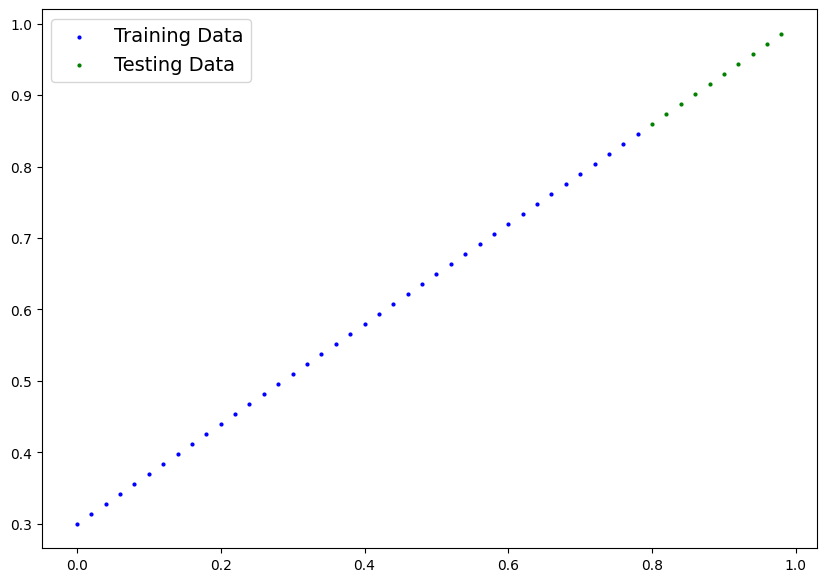

In [6]:
plot_predictions()

### 2. Build model

* Our first PyTorch model

In [7]:
# Create linear regression model class

class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
    self.bais = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    # Forward method to define the computation in the model
  def forward(self, X: torch.Tensor) -> torch.Tensor:
    return self.weights * X + self.bais

### Checking the contents of our PyTorch model

In [8]:
# Create a seed

torch.manual_seed(42)

# Create a instance of a model
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [9]:
# List named parameters

model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bais', tensor([0.1288]))])

In [10]:
# Making predictions with our model

with torch.inference_mode():
  y_preds = model_0(x_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

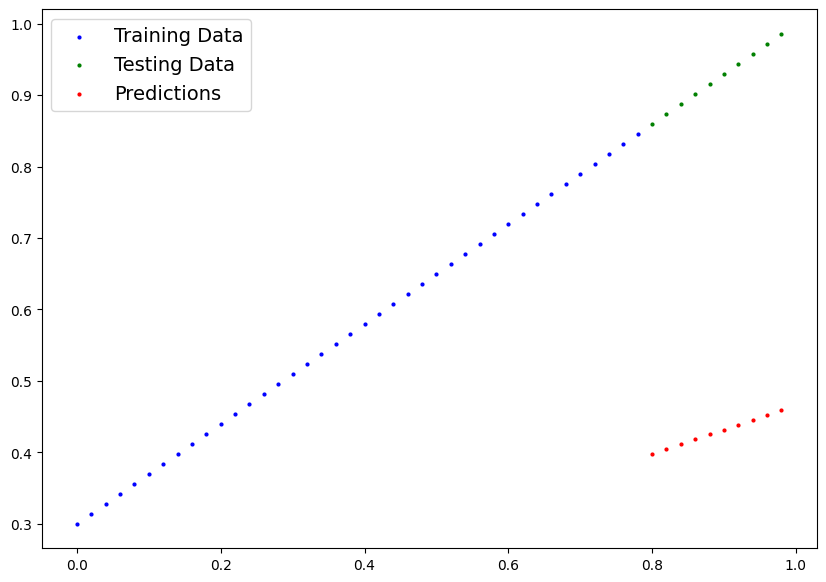

In [11]:
plot_predictions(predictions=y_preds)

### 3. Train a model

In [12]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [13]:
# Check out our model's parameters

model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bais', tensor([0.1288]))])

In [14]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup a optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1) # learn rate
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

### Building a training loop in PyTorch

In [15]:
from numpy import test
torch.manual_seed(42)

# An epoch is one loop through the data(this is a hyperparameter because we set it our self)
epochs = 200

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop through the data

for epoch in range(epochs):
  # set the model to train mode
  model_0.train()

  #1. Forward pass
  y_pred = model_0(x_train)

  #2. calculate the loss
  loss = loss_fn(y_pred, y_train)
  print(f"Loss: {loss}")

  #3. optimizer zero grad
  optimizer.zero_grad()

  #4. perform backpropagation on the loss
  loss.backward()

  #5. step the optimizer
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    test_pred = model_0(x_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
    print(model_0.state_dict())

Loss: 0.31288138031959534
Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.35982614755630493
OrderedDict({'weights': tensor([0.3757]), 'bais': tensor([0.2288])})
Loss: 0.1976713389158249
Loss: 0.08682452142238617
Loss: 0.04956193268299103
Loss: 0.04610266909003258
Loss: 0.04258420318365097
Loss: 0.03921257331967354
Loss: 0.03573219105601311
Loss: 0.032322462648153305
Loss: 0.028880193829536438
Loss: 0.025432366877794266
Epoch: 10 | Loss: 0.025432366877794266 | Test loss: 0.05427704378962517
OrderedDict({'weights': tensor([0.5898]), 'bais': tensor([0.3438])})
Loss: 0.022041911259293556
Loss: 0.019071225076913834
Loss: 0.018788114190101624
Loss: 0.039773717522621155
Loss: 0.07543627172708511
Loss: 0.039773717522621155
Loss: 0.07543627172708511
Loss: 0.039773717522621155
Loss: 0.07543627172708511
Loss: 0.039773717522621155
Epoch: 20 | Loss: 0.039773717522621155 | Test loss: 0.11934101581573486
OrderedDict({'weights': tensor([0.6122]), 'bais': tensor([0.2588])})
Loss: 0.0754362717270851

In [16]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6512])), ('bais', tensor([0.3588]))])

In [17]:
weight, bais

(0.7, 0.3)

In [18]:
with torch.inference_mode():
  y_preds_new = model_0(x_test)

y_preds_new

tensor([[0.8798],
        [0.8928],
        [0.9058],
        [0.9188],
        [0.9319],
        [0.9449],
        [0.9579],
        [0.9709],
        [0.9840],
        [0.9970]])

/tmp/ipykernel_5137/197798666.py:4: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")


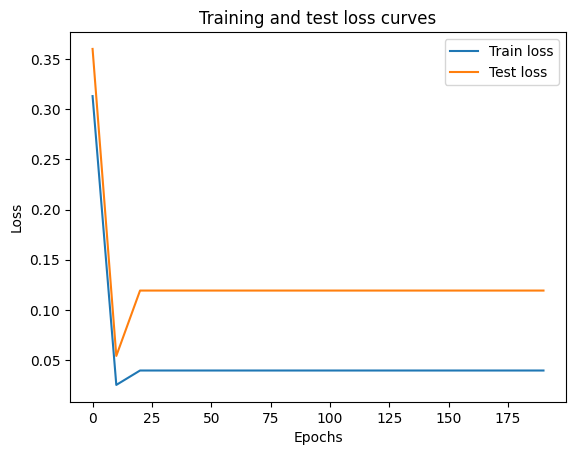

In [19]:
# plot the loss curve
import numpy as np

plt.plot(epoch_count, np.array(torch.tensor(loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

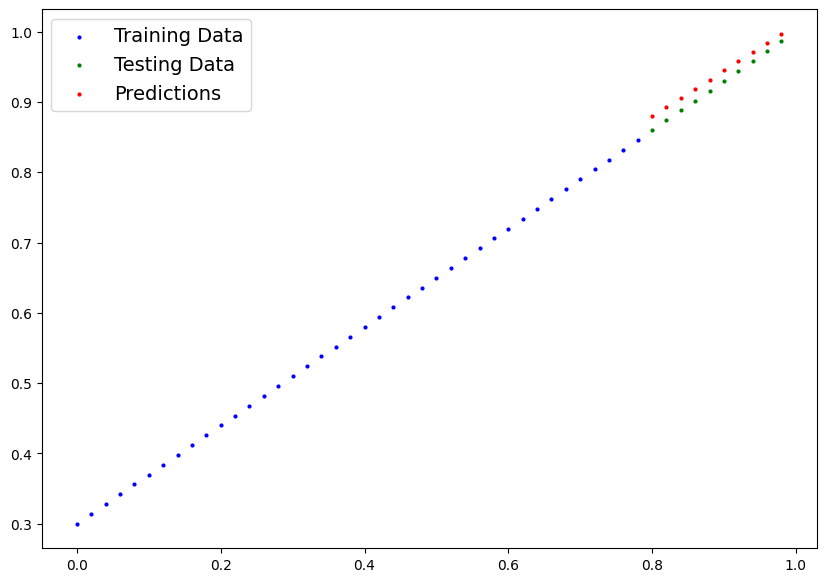

In [20]:
plot_predictions(predictions=y_preds_new)

### 4. Saving a Model in PyTorch

There are three main methods to save and load model in PyTorch.

1. `torch.save()` - Allows you to save a model in pickle format
2. `torch.load()` - Allows you to load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - Allows you to load a model's saved state dictionary

In [21]:
# saving our pyTorch model

from pathlib import Path

#1. Create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. model save path
MODEL_NAME = "01_pytorch_workflow_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

#3. save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model.pth


### 5. Loading a PyTorch model

In [22]:
load_model = LinearRegressionModel()
load_model.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [23]:
load_model.state_dict()

OrderedDict([('weights', tensor([0.6512])), ('bais', tensor([0.3588]))])

In [24]:
# To make predications with our loaded model

load_model.eval()
with torch.inference_mode():
  loaded_model_preds = load_model(x_test)

loaded_model_preds

tensor([[0.8798],
        [0.8928],
        [0.9058],
        [0.9188],
        [0.9319],
        [0.9449],
        [0.9579],
        [0.9709],
        [0.9840],
        [0.9970]])

In [25]:
model_0.eval()
with torch.inference_mode():
  y_preds = model_0(x_test)

y_preds

tensor([[0.8798],
        [0.8928],
        [0.9058],
        [0.9188],
        [0.9319],
        [0.9449],
        [0.9579],
        [0.9709],
        [0.9840],
        [0.9970]])

In [26]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# 6. Putting it all together

In [27]:
import torch
from torch import nn
import matplotlib.pyplot as plt


torch.__version__

'2.10.0+cu128'

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print (f"Using device: {device}")

Using device: cuda


## 6.1 Data

In [29]:
# create some data
weight = 0.5
bias = 0.2

# create some range
start = 0
end = 1
step = 0.015

# create X and Y
X = torch.arange(start, end, step).unsqueeze(dim = 1)
Y = weight * X + bais
X[:10], Y[:10]

(tensor([[0.0000],
         [0.0150],
         [0.0300],
         [0.0450],
         [0.0600],
         [0.0750],
         [0.0900],
         [0.1050],
         [0.1200],
         [0.1350]]),
 tensor([[0.3000],
         [0.3075],
         [0.3150],
         [0.3225],
         [0.3300],
         [0.3375],
         [0.3450],
         [0.3525],
         [0.3600],
         [0.3675]]))

In [30]:
# visualize data

def plot_predictions(train_data=x_train,
                     train_labels=y_train,
                     test_data=x_test,
                     test_labels=y_test,
                     predictions=None):

 plt.figure(figsize=(10,7))
 # plot tarining data
 plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
 # plot test data
 plt.scatter(test_data, test_labels, c="g", s=4, label="Testing Data")

 if predictions is not None:
   # plot predictions
   plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")
 plt.legend(prop={"size":14});

In [31]:
# split data
train_split = int(0.8 * len(X))
X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]
len(X_train), len(Y_train), len(X_test), len(Y_test)

(53, 53, 14, 14)

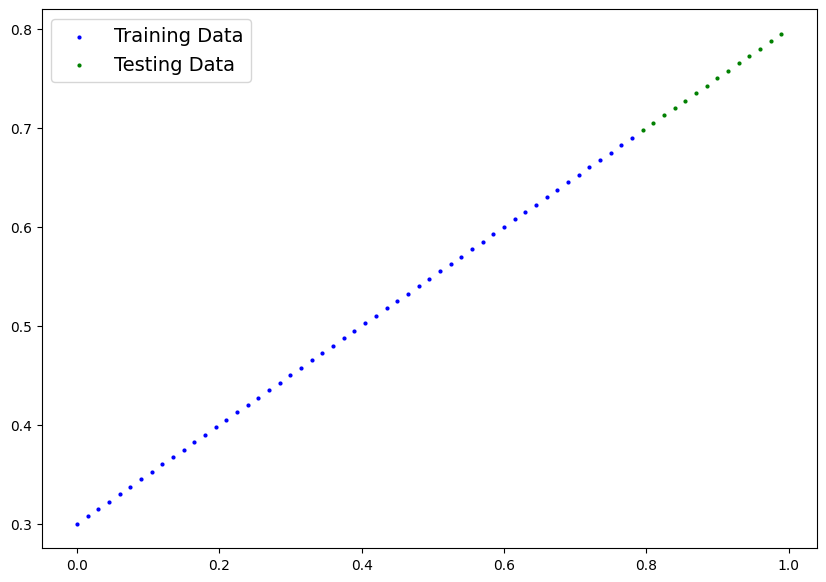

In [32]:
# plot the data
plot_predictions(X_train, Y_train, X_test, Y_test)

## 6.2 Buliding a PyTorch Linear model

In [33]:
# Creating a Linear model by subclassing nn.module
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    # use nn.Linear() fro creating a model parameters
    self.linear_layer = nn.Linear(in_features=1, out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [34]:
# Check the model current device
next(model_1.parameters()).device

device(type='cpu')

In [35]:
# set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.3 Training

In [36]:
# Set up loss function
loss_fn = nn.L1Loss()

# Set up optimizer
optimizer = torch.optim.SGD(lr=0.01, params=model_1.parameters())

In [44]:
import torch
from torch import nn
import matplotlib.pyplot as plt


# Training Loop
torch.manual_seed(42)

epochs = 300

# Put data on the target device
X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

for epoch in range(epochs):
  model_1.train()

  # Forward pass
  y_pred = model_1(X_train)

  # Calculate the loss
  loss = loss_fn(y_pred, Y_train) # Changed 'Loss' to 'loss'

  # optimizer grad
  optimizer.zero_grad()

  # back propgation
  loss.backward()

  # optmizer step
  optimizer.step()

  #Testing
  model_1.eval() # Added parentheses
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred, Y_test)

  if epoch % 10 == 0:
    print(f"epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

epoch: 0 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 10 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 20 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 30 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 40 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 50 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 60 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 70 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 80 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 90 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 100 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 110 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 120 | Loss: 0.0031226312275975943 | Test loss: 0.006588608492165804
epoch: 130 | Loss: 0.003122631227597

In [45]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.5075]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3002], device='cuda:0'))])

In [47]:
weight, bias

(0.5, 0.2)

### 6.4 Making and evaluating predictions

In [48]:
model_1.eval()

with torch.inference_mode():
  y_pred = model_1(X_test)

y_pred

tensor([[0.7037],
        [0.7113],
        [0.7189],
        [0.7265],
        [0.7341],
        [0.7417],
        [0.7493],
        [0.7569],
        [0.7646],
        [0.7722],
        [0.7798],
        [0.7874],
        [0.7950],
        [0.8026]], device='cuda:0')

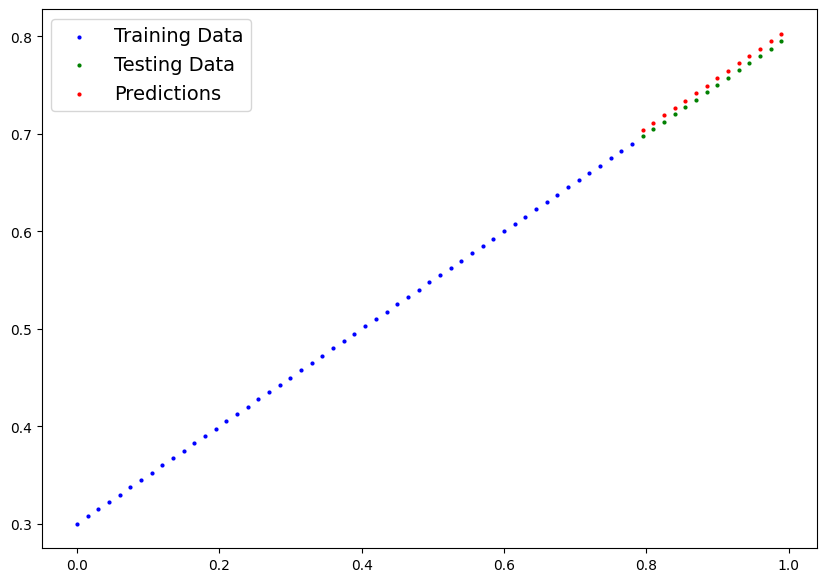

In [50]:
plot_predictions(train_data=X_train.cpu(), train_labels=Y_train.cpu(), test_data=X_test.cpu(), test_labels=Y_test.cpu(), predictions=y_pred.cpu())

### 6.5 Saving and Loading model

In [51]:
from pathlib import Path

MODEL_NAME = "001_pytorch_workflow_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

#3. save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/001_pytorch_workflow_model.pth


In [53]:
# Load a model
load_model_1 = LinearRegressionModelV2()
load_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

<All keys matched successfully>

In [56]:
load_model_1.eval()
load_model_1.to(device)
with torch.inference_mode():
  load_model_1_preds = load_model_1(X_test)

load_model_1_preds == y_pred

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')